In [8]:
import pandas as pd

data = {
    "Order_ID": [101, 102, 103, 104, 105, 106],
    "Customer": ["Saad", "Rafay", "Anas", "Ayan", "Ahmed", "Umer"],
    "Product": ["Laptop", "Phone", "Laptop", "Tablet", "Phone", "Laptop"],
    "Price": [1200, 800, 1200, 600, 800, 1200],
    "Quantity": [1, 2, 1, 3, 1, 2],
    "City": ["Karachi", "Lahore", "Karachi", "Faisalabad", "Lahore", "Quetta"]
}
df = pd.DataFrame(data)
print('\t\t##Initial Dataset##')
print(df)

		##Initial Dataset##
   Order_ID Customer Product  Price  Quantity       City
0       101     Saad  Laptop   1200         1    Karachi
1       102    Rafay   Phone    800         2     Lahore
2       103     Anas  Laptop   1200         1    Karachi
3       104     Ayan  Tablet    600         3  Faislabad
4       105    Ahmed   Phone    800         1     Lahore
5       106     Umer  Laptop   1200         2     Quetta


In [9]:
print('Shape of DataSet',df.shape)

Shape of DataSet (6, 6)


In [10]:
print('Column Names',df.columns)

Column Names Index(['Order_ID', 'Customer', 'Product', 'Price', 'Quantity', 'City'], dtype='object')


In [12]:
print('DataType',df.dtypes)

DataType Order_ID     int64
Customer    object
Product     object
Price        int64
Quantity     int64
City        object
dtype: object


In [14]:
print('Statistic',df.describe())

Statistic          Order_ID        Price  Quantity
count    6.000000     6.000000  6.000000
mean   103.500000   966.666667  1.666667
std      1.870829   265.832027  0.816497
min    101.000000   600.000000  1.000000
25%    102.250000   800.000000  1.000000
50%    103.500000  1000.000000  1.500000
75%    104.750000  1200.000000  2.000000
max    106.000000  1200.000000  3.000000


In [15]:
df['Total_Sale']= df['Price'] * df['Quantity']
print('Dataset after adding Total Sales column')
print(df)

Dataset after adding Total Sales column
   Order_ID Customer Product  Price  Quantity       City  Total_Sale
0       101     Saad  Laptop   1200         1    Karachi        1200
1       102    Rafay   Phone    800         2     Lahore        1600
2       103     Anas  Laptop   1200         1    Karachi        1200
3       104     Ayan  Tablet    600         3  Faislabad        1800
4       105    Ahmed   Phone    800         1     Lahore         800
5       106     Umer  Laptop   1200         2     Quetta        2400


In [16]:
print('Check Missing Values in Dataset:')
print(df.isnull().sum())

Check Missing Values in Dataset:
Order_ID      0
Customer      0
Product       0
Price         0
Quantity      0
City          0
Total_Sale    0
dtype: int64


In [17]:
laptop_orders = df[df['Product'] == 'Laptop']
print('Laptop Orders:')
print(laptop_orders)

Laptop Orders:
   Order_ID Customer Product  Price  Quantity     City  Total_Sale
0       101     Saad  Laptop   1200         1  Karachi        1200
2       103     Anas  Laptop   1200         1  Karachi        1200
5       106     Umer  Laptop   1200         2   Quetta        2400


In [20]:
sales_by_product = df.groupby('Product')['Total_Sale'].sum()
print('Sales by product')
print(sales_by_product)

Sales by product
Product
Laptop    4800
Phone     2400
Tablet    1800
Name: Total_Sale, dtype: int64


In [21]:
sales_by_city = df.groupby('City')['Total_Sale'].sum()
print('Sales by city')
print(sales_by_city)

Sales by city
City
Faislabad    1800
Karachi      2400
Lahore       2400
Quetta       2400
Name: Total_Sale, dtype: int64


In [23]:
sorted_sales = df.sort_values(by='Total_Sale',ascending = False)
print('Sorted by Highest sales')
print(sorted_sales)

Sorted by Highest sales
   Order_ID Customer Product  Price  Quantity       City  Total_Sale
5       106     Umer  Laptop   1200         2     Quetta        2400
3       104     Ayan  Tablet    600         3  Faislabad        1800
1       102    Rafay   Phone    800         2     Lahore        1600
0       101     Saad  Laptop   1200         1    Karachi        1200
2       103     Anas  Laptop   1200         1    Karachi        1200
4       105    Ahmed   Phone    800         1     Lahore         800


In [24]:
print('Total Revenue:',df['Total_Sale'].sum())
print('Average Order Value:', df['Total_Sale'].mean())
print('Maximum Sale:',df['Total_Sale'].max())

Total Revenue: 9000
Average Order Value: 1500.0
Maximum Sale: 2400


In [25]:
pivot = pd.pivot_table(
    df,
    values ='Total_Sale',
    index='City',
    columns='Product',
    aggfunc='sum'
)
print('pivot table')
print(pivot)

pivot table
Product    Laptop   Phone  Tablet
City                             
Faislabad     NaN     NaN  1800.0
Karachi    2400.0     NaN     NaN
Lahore        NaN  2400.0     NaN
Quetta     2400.0     NaN     NaN


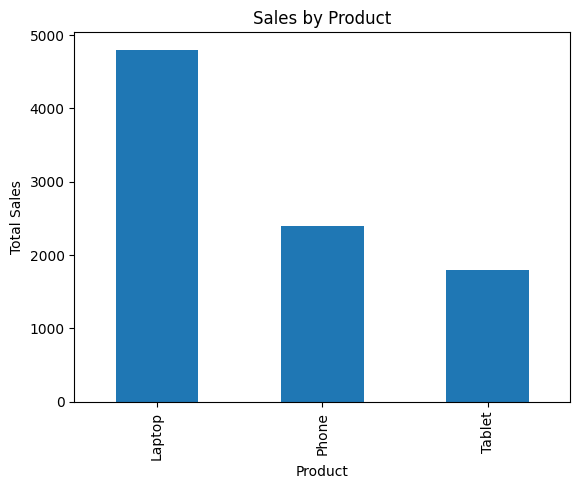

In [26]:
import matplotlib.pyplot as plt

sales_by_product.plot(kind="bar")
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()